# Implied Volatility Surface Prediction for NIFTY Options

### Finance Club IIT Roorkee — Open Projects 2026

**Objective:** Predict missing implied volatility values across strikes and timestamps in the NIFTY options volatility surface.

**Approach Overview**

This notebook combines financial surface reconstruction with causal machine learning:

1. Weighted polynomial volatility-smile fitting across strikes, including dedicated handling for boundary-strike extrapolation. This reconstruction method is referred to throughout the notebook as **V11**.
2. Expiry-day specific surface handling.
3. Residual error modeling using walk-forward causal learning.
4. Sparse-surface regime adjustments for expiry-day edge cases.
5. Fully reproducible submission generation.

**Key Design Principles**

- Preserve volatility smile structure across strikes.
- Treat expiry day as a distinct market regime.
- Avoid lookahead bias through strictly causal training.
- Use machine learning only as a residual correction layer.
- Generate a submission file directly from the final reconstructed surface.

---

**Evaluation Metric:** Mean Squared Error (MSE)

**Dataset:** NIFTY Options Implied Volatility Surface

**Final Model:** V11 Smile Reconstruction + Walk-Forward Residual Learning

## 1. Environment Setup

Import required libraries, configure reproducibility settings, and initialize the analysis environment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import datetime
import warnings
warnings.filterwarnings('ignore')

# for reproducibility
np.random.seed(42)

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Dataset Loading and Missingness Analysis

The dataset contains implied volatility observations for NIFTY options across multiple strikes and timestamps.

Before constructing a reconstruction model, we examine the overall structure of missingness in the volatility surface.

The primary questions are:

- How sparse is the surface?
- Are missing values isolated or clustered?
- Are gaps short enough for cross-sectional reconstruction across strikes to be effective?

These observations guide the design of the reconstruction methodology developed later in the notebook.

In [2]:
# loading dataset
df = pd.read_csv('dataset.csv')

# parsing datetime
df['datetime'] = pd.to_datetime(df['datetime'], format='%d-%m-%Y %H:%M')

# extracting time features
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['minute'] = df['datetime'].dt.minute
df['time_index'] = range(len(df))

# identifying option columns
option_cols = [col for col in df.columns if 'CE' in col or 'PE' in col]
ce_cols_sorted = sorted([c for c in option_cols if 'CE' in c], key=lambda x: int(x[12:17]))
pe_cols_sorted = sorted([c for c in option_cols if 'PE' in c], key=lambda x: int(x[12:17]))

print(f"Dataset shape: {df.shape}")
print(f"Timestamps: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Option columns: {len(option_cols)} ({len(ce_cols_sorted)} CE, {len(pe_cols_sorted)} PE)")
print(f"Total missing values: {df[option_cols].isnull().sum().sum()}")
print(f"Missing percentage: {100 * df[option_cols].isnull().sum().sum() / (df.shape[0] * len(option_cols)):.1f}%")

Dataset shape: (975, 34)
Timestamps: 2026-01-07 09:15:00 to 2026-01-27 15:25:00
Option columns: 28 (14 CE, 14 PE)
Total missing values: 5460
Missing percentage: 20.0%


In [3]:
# missing value analysis
total_cells = df.shape[0] * len(option_cols)
missing_cells = df[option_cols].isnull().sum().sum()
missing_per_row = df[option_cols].isnull().sum(axis=1)

print("=== Missing Value Analysis ===")
print(f"Total option cells: {total_cells}")
print(f"Missing cells: {missing_cells} ({100*missing_cells/total_cells:.1f}%)")
print(f"Average missing per row: {missing_per_row.mean():.2f}")
print(f"Max missing per row: {missing_per_row.max()}")

# gap size analysis
gap_lengths = []
for col in option_cols:
    current_gap = 0
    for val in df[col]:
        if pd.isna(val):
            current_gap += 1
        else:
            if current_gap > 0:
                gap_lengths.append(current_gap)
                current_gap = 0

print(f"\n=== Gap Analysis ===")
print(f"Total gaps: {len(gap_lengths)}")
print(f"Average gap length: {np.mean(gap_lengths):.2f}")
print(f"Max gap length: {max(gap_lengths)}")

=== Missing Value Analysis ===
Total option cells: 27300
Missing cells: 5460 (20.0%)
Average missing per row: 5.60
Max missing per row: 14

=== Gap Analysis ===
Total gaps: 4325
Average gap length: 1.26
Max gap length: 7


### Observation

Although a significant number of implied volatility values are missing, most gaps are relatively short compared to the size of the strike grid.

This suggests that nearby strikes often remain observable even when a target value is missing. Consequently, a cross-sectional reconstruction approach based on the shape of the volatility smile is likely to be effective.

## 3. Volatility Surface Structure

Implied volatility typically varies systematically across strike prices rather than remaining constant.

At a fixed timestamp, the option chain often exhibits a volatility smile or skew, where neighboring strikes have strongly related implied volatilities.

Understanding this cross-sectional structure is critical because the reconstruction model will infer missing values from the surrounding shape of the volatility surface.

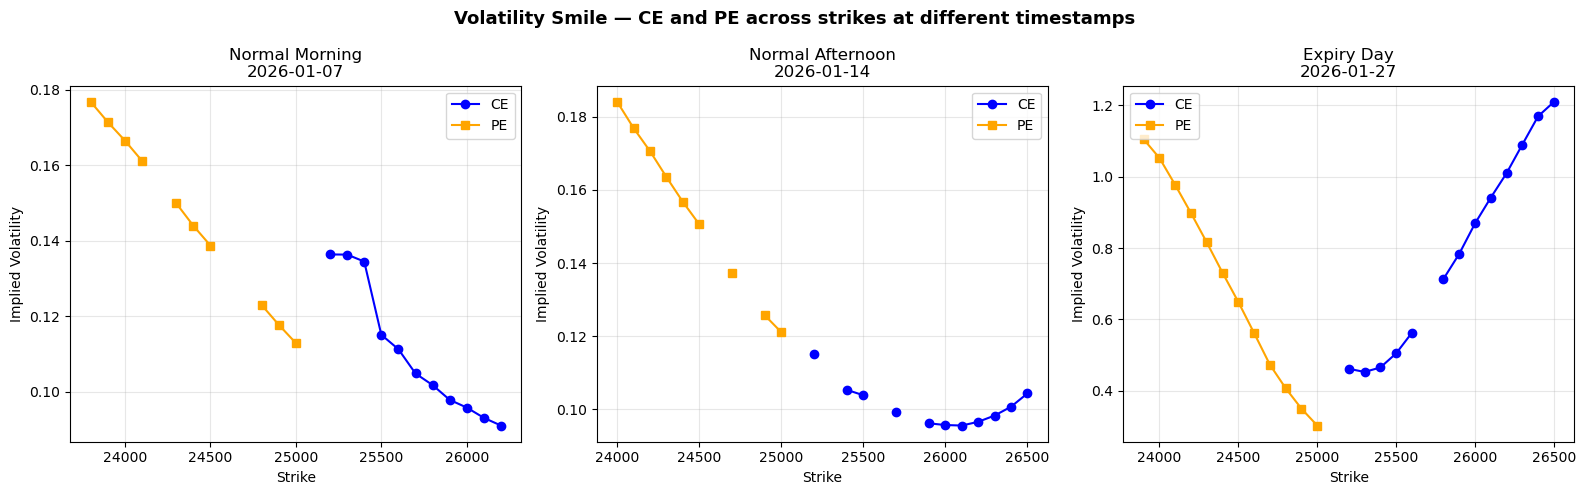

In [4]:
# =========================================================
# VOLATILITY SMILE VISUALIZATION
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

timestamps = [50, 400, 950]
labels = ['Normal Morning\n2026-01-07', 'Normal Afternoon\n2026-01-14', 'Expiry Day\n2026-01-27']

for i, (ts, label) in enumerate(zip(timestamps, labels)):
    row = df.iloc[ts]
    
    ce_strikes = [int(col[12:17]) for col in ce_cols_sorted]
    ce_vals = [row[col] for col in ce_cols_sorted]
    pe_strikes = [int(col[12:17]) for col in pe_cols_sorted]
    pe_vals = [row[col] for col in pe_cols_sorted]
    
    axes[i].plot(ce_strikes, ce_vals, marker='o', label='CE', color='blue')
    axes[i].plot(pe_strikes, pe_vals, marker='s', label='PE', color='orange')
    axes[i].set_title(label)
    axes[i].set_xlabel('Strike')
    axes[i].set_ylabel('Implied Volatility')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Volatility Smile — CE and PE across strikes at different timestamps', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Observation

The volatility surface exhibits smooth cross-sectional behavior across strikes for both call and put options.

Rather than treating missing values as independent observations, reconstruction methods should exploit the geometric structure of the smile. This motivates the use of curve-fitting techniques across strikes, which later form the basis of the V11 model.

## 4. Expiry-Day Regime Analysis

Option market dynamics change significantly on expiry day due to accelerated time decay and evolving market expectations.

To determine whether expiry observations should be modeled separately, we compare volatility levels across trading days and examine how the surface behaves near contract expiration.

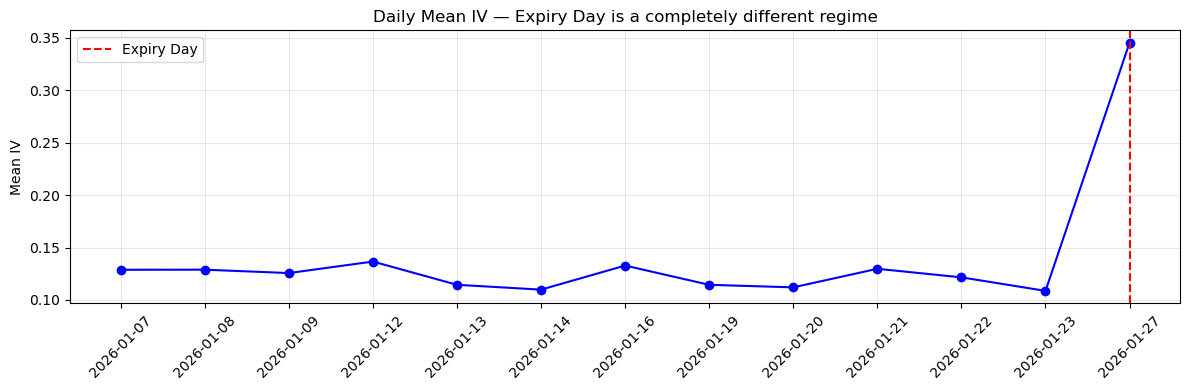

Normal days mean IV: 0.1354
Expiry day mean IV:  0.7531
Expiry is 5.6x higher than normal days


In [5]:
# expiry day regime analysis
expiry_date = datetime.date(2026, 1, 27)

daily_mean = df.groupby('date')['NIFTY27JAN2625200CE'].mean()

plt.figure(figsize=(12, 4))
plt.plot(range(len(daily_mean)), daily_mean.values, marker='o', color='blue')
plt.xticks(range(len(daily_mean)), [str(d) for d in daily_mean.index], rotation=45)
plt.axvline(x=len(daily_mean)-1, color='red', linestyle='--', label='Expiry Day')
plt.title('Daily Mean IV — Expiry Day is a completely different regime')
plt.ylabel('Mean IV')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

normal_mean = df[df['date'] != expiry_date][option_cols].mean().mean()
expiry_mean = df[df['date'] == expiry_date][option_cols].mean().mean()
print(f"Normal days mean IV: {normal_mean:.4f}")
print(f"Expiry day mean IV:  {expiry_mean:.4f}")
print(f"Expiry is {expiry_mean/normal_mean:.1f}x higher than normal days")

### Observation

Expiry-day implied volatilities differ materially from those observed during normal trading sessions.

This indicates the presence of a distinct market regime near expiration. Consequently, the reconstruction framework incorporates expiry-aware behavior rather than applying a single surface model uniformly across all dates.

## 5. Utility Functions and Validation Framework

Before constructing the reconstruction model, we define helper functions for strike extraction and model evaluation.

A controlled masking-based validation framework is also introduced. The framework temporarily hides observed implied volatility values and measures reconstruction accuracy against the known ground truth.

This provides an objective way to compare alternative reconstruction approaches while avoiding leakage from hidden targets.

In [6]:
def get_strike(col_name):
    """
    Extract strike price from an option column name.

    Example:
    NIFTY27JAN2625200CE -> 25200
    """
    return int(col_name[12:17])

def run_validation(predict_fn, df, option_cols, ce_cols_sorted, pe_cols_sorted, expiry_date, seed=42):
    """
    Evaluate a reconstruction method by randomly masking
    a subset of observed implied volatility values and
    comparing reconstructed values against ground truth.
    
    Parameters
    ----------
    predict_fn : callable
        Reconstruction function used to fill missing values.
    
    Returns
    -------
    float
        Mean squared reconstruction error.
    """
    np.random.seed(seed)
    actual = []
    predicted = []
    
    for col in option_cols:
        observed_indices = df.index[df[col].notna()].tolist()
        hide_count = int(len(observed_indices) * 0.2)
        hide_indices = list(np.random.choice(observed_indices, size=hide_count, replace=False))
        
        df_temp = df.copy()
        df_temp.loc[hide_indices, col] = np.nan
        
        for idx in hide_indices:
            is_expiry = df.loc[idx, 'date'] == expiry_date
            filled_row = predict_fn(df_temp.loc[idx], ce_cols_sorted, pe_cols_sorted, is_expiry)
            actual.append(df.loc[idx, col])
            predicted.append(filled_row[col] if pd.notna(filled_row[col]) else 0)
    
    return mean_squared_error(actual, predicted)

print("Validation framework ready")

Validation framework ready


### Validation Philosophy

The evaluation procedure uses only information available at the prediction timestamp and compares reconstructed values against known observations.

This closely mirrors the competition objective, where missing implied volatilities must be estimated from the observed structure of the volatility surface without access to the hidden target values.

## 6. V11 Volatility Smile Reconstruction

The primary reconstruction model used in this project is a weighted volatility-smile fitting procedure referred to as **V11**.

The motivation behind V11 is that implied volatility surfaces exhibit strong cross-sectional structure across strikes. Rather than estimating missing values independently, the model reconstructs them from the shape of the observed volatility smile at the same timestamp.

### Methodology

For each missing implied volatility value:

1. All observed strikes from the same option side (CE or PE) are collected.
2. Nearby strikes receive higher importance through distance-based weighting.
3. A weighted polynomial curve is fitted to the observed smile.
4. The missing strike is estimated from the fitted curve.
5. A minimum volatility floor is applied to prevent unrealistic predictions.

### Expiry-Day Adjustments

Expiry-day surfaces exhibit significantly different curvature compared to normal trading sessions.

To account for this behavior:

* Higher-order smile flexibility is permitted on expiry observations.
* Boundary-strike predictions use stable linear continuation rather than direct polynomial extrapolation.
* Additional safeguards are applied to prevent instability at the edges of the strike grid.

The resulting V11 prediction serves as the foundational estimate for all subsequent residual-learning stages.


In [7]:
def fill_row_curve_v11(row, ce_cols_sorted, pe_cols_sorted, is_expiry=False):
    """
    Weighted polynomial smile fitting.
    
    For each missing strike:
    - Collects all observed strikes on same side (CE or PE)
    - Assigns distance-based weights: w = 1 / (1 + distance)
    - Fits weighted polynomial (degree 2 normal, degree 3 expiry)
    - Predicts missing strike from fitted curve
    - Applies floor to prevent unrealistic values
    """
    row_filled = row.copy()
    
    for cols_sorted in [ce_cols_sorted, pe_cols_sorted]:
        for missing_col in cols_sorted:
            if pd.notna(row[missing_col]):
                continue
            
            target_strike = get_strike(missing_col)
            observed_strikes = []
            observed_ivs = []
            weights = []
            
            for col in cols_sorted:
                val = row[col]
                if pd.notna(val):
                    strike = get_strike(col)
                    observed_strikes.append(strike)
                    observed_ivs.append(val)
                    distance = abs(strike - target_strike)
                    weights.append(1 / (1 + distance))
            
            if len(observed_strikes) < 2:
                continue
            
            degree = 3 if is_expiry else 2
            degree = min(degree, len(observed_strikes) - 1)
            
            coeffs = np.polyfit(
                observed_strikes,
                observed_ivs,
                deg=degree,
                w=weights
            )
            
            # =====================================================
            # STABLE EXPIRY EDGE EXTRAPOLATION
            # =====================================================
            
            left_edge = (
                target_strike < min(observed_strikes)
            )
            
            right_edge = (
                target_strike > max(observed_strikes)
            )

            is_edge_extrapolation = (
                left_edge or right_edge
            )
            
            # use stable linear continuation ONLY for
            # expiry edge extrapolation
            if (
                is_expiry
                and is_edge_extrapolation
                and len(observed_strikes) >= 2
            ):
            
                x_sorted = np.array(sorted(observed_strikes))
            
                y_sorted = np.array([
                    observed_ivs[
                        observed_strikes.index(x)
                    ]
                    for x in x_sorted
                ])

                # LEFT EDGE
                if left_edge:
            
                    x1 = x_sorted[0]
                    x2 = x_sorted[1]
            
                    y1 = y_sorted[0]
                    y2 = y_sorted[1]
            
                    anchor_x = x1
                    anchor_y = y1

                # RIGHT EDGE
                else:
            
                    x1 = x_sorted[-2]
                    x2 = x_sorted[-1]
            
                    y1 = y_sorted[-2]
                    y2 = y_sorted[-1]
            
                    anchor_x = x2
                    anchor_y = y2
            
                slope = (
                    (y2 - y1)
                    / (x2 - x1)
                )
            
                predicted = (
                    anchor_y
                    + slope * (
                        target_strike - anchor_x
                    )
                )

            # normal polynomial prediction
            else:
            
                predicted = np.polyval(
                    coeffs,
                    target_strike
                )

            
            min_iv = min(observed_ivs)
            floor = max(min_iv * 0.25, 0.01)
            row_filled[missing_col] = max(predicted, floor)
    
    return row_filled

print("V11 reconstruction model initialized")

V11 reconstruction model initialized


### Role of V11 in the Final Pipeline

V11 is intentionally designed as a financially motivated reconstruction model rather than a purely machine-learning approach.

The model captures the dominant geometry of the volatility surface and produces robust baseline estimates across strikes. Subsequent machine-learning components focus only on correcting the residual errors that remain after V11 reconstruction.


## 7. Residual Dataset Construction

After generating baseline predictions using V11, the next objective is to model the systematic reconstruction errors that remain.

To achieve this, a residual-learning dataset is constructed.

For each observed implied volatility value:

1. The value is temporarily hidden.
2. V11 reconstructs the missing value.
3. The reconstruction error is computed.
4. Features describing market state, strike location, moneyness, time, and V11 output are recorded.

This converts the problem from direct volatility prediction into residual prediction, allowing machine learning to focus only on correcting the remaining reconstruction error.


In [8]:
# =========================================================
# BUILD FULL RESIDUAL DATASET
# (used later for causal walk-forward training)
# =========================================================

residual_rows = []

for col in option_cols:

    cols_sorted = (
        ce_cols_sorted if 'CE' in col
        else pe_cols_sorted
    )

    for idx in df.index:

        if pd.isna(df.loc[idx, col]):
            continue

        actual_iv = df.loc[idx, col]

        # =================================================
        # HIDE CURRENT OBSERVED CELL
        # =================================================

        row_temp = df.loc[idx].copy()
        row_temp[col] = np.nan

        # =================================================
        # V11 PREDICTION
        # =================================================

        filled_row = fill_row_curve_v11(
            row_temp,
            ce_cols_sorted,
            pe_cols_sorted,
            is_expiry=(
                df.loc[idx, 'date'] == expiry_date
            )
        )

        v11_pred = filled_row[col]

        if pd.isna(v11_pred):
            continue

        # =================================================
        # RESIDUAL TARGET
        # =================================================

        residual = actual_iv - v11_pred

        residual_rows.append({

            'idx': idx,
            'col': col,

            'residual': residual,

            'strike': get_strike(col),

            'is_call': (
                1 if 'CE' in col else 0
            ),

            'is_expiry': (
                1 if df.loc[idx, 'date'] == expiry_date
                else 0
            ),

            'time_index': df.loc[idx, 'time_index'],
            'hour': df.loc[idx, 'hour'],
            'minute': df.loc[idx, 'minute'],

            'underlying_price':
                df.loc[idx, 'underlying_price'],

            'moneyness':
                get_strike(col)
                / df.loc[idx, 'underlying_price'],

            'v11_pred_feature': v11_pred
        })

residual_df = pd.DataFrame(residual_rows)

print(
    f"Residual dataset built: "
    f"{len(residual_df)} samples"
)

Residual dataset built: 21840 samples


### Residual Target Definition

For each observed cell:

Residual = Actual IV − V11 Prediction

A positive residual indicates underestimation by V11, while a negative residual indicates overestimation.

The residual-learning model is trained exclusively on these reconstruction errors.

## 8. Walk-Forward Learning Configuration

The residual-learning model operates in a strictly causal manner.

Instead of training on the full dataset, the model is periodically retrained using a rolling historical window. This prevents information leakage from future timestamps and more closely reflects how a model would operate in a live market environment.

The following configuration defines:

- Features used for residual prediction.
- Rolling training window size.
- Retraining frequency.
- Residual correction limits.

In [9]:
# =========================================================
# WALK-FORWARD SETTINGS
# =========================================================

feature_cols = [

    'strike',
    'is_call',
    'is_expiry',

    'time_index',
    'hour',
    'minute',

    'underlying_price',
    'moneyness',

    'v11_pred_feature'
]

# walk-forward parameters
window_size = 200
retrain_every = 25

# residual clipping
max_correction = 0.02

print("Walk-forward learning configuration initialized")
print(f"Window size: {window_size}")
print(f"Retrain every: {retrain_every}")

Walk-forward learning configuration initialized
Window size: 200
Retrain every: 25


## 9. Walk-Forward Causal Residual Learning

The final prediction framework combines V11 reconstruction with causal residual correction.

### Stage 1 — Base Reconstruction

Missing implied volatilities are first estimated using the V11 smile-fitting model.

### Stage 2 — Rolling Residual Training

An XGBoost regressor is periodically retrained using only historical residual observations available prior to the current timestamp.

This ensures that no future information is incorporated into the prediction process.

### Stage 3 — Residual Correction

The trained model predicts a residual correction which is added to the V11 estimate.

### Sparse-Surface Regime Handling

Certain regions of the volatility surface exhibit different behavior, particularly near expiry and near the edges of the strike grid.

Additional adaptive trust scaling is therefore applied when:

* Expiry-day observations are encountered.
* Neighboring strike information is sparse.
* Surface geometry becomes unstable.

These adjustments are designed to preserve robustness while allowing machine learning to contribute where it is most beneficial.


In [14]:
# =========================================================
# WALK-FORWARD CAUSAL RESIDUAL LEARNING
# =========================================================

df_final_hybrid = df.copy()

current_model = None

for idx in df.index:

    is_expiry = (
        df.loc[idx, 'date'] == expiry_date
    )

    # =====================================================
    # STEP 1: V11 BASE PREDICTION
    # =====================================================

    filled_row = fill_row_curve_v11(
        df_final_hybrid.loc[idx],
        ce_cols_sorted,
        pe_cols_sorted,
        is_expiry
    )

    # =====================================================
    # STEP 2: PERIODIC CAUSAL RETRAINING
    # =====================================================

    should_retrain = (
        idx >= window_size
        and idx % retrain_every == 0
    )

    if should_retrain:

        train_start = idx - window_size
        train_end = idx - 1

        train_df = residual_df[
            (residual_df['idx'] >= train_start)
            &
            (residual_df['idx'] <= train_end)
        ]

        if len(train_df) > 100:

            X_train = train_df[feature_cols]
            y_train = train_df['residual']

            current_model = XGBRegressor(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=4,
                random_state=42
            )

            current_model.fit(
                X_train,
                y_train,
                verbose=False
            )

            print(
                f"Retrained at row {idx} "
                f"using rows "
                f"{train_start}-{train_end}"
            )

    # =====================================================
    # STEP 3: FINAL PREDICTIONS
    # =====================================================

    for col in option_cols:

        if pd.notna(df.loc[idx, col]):
            continue

        v11_pred = filled_row[col]

        if pd.isna(v11_pred):
            df_final_hybrid.loc[idx, col] = 0
            continue
        
        # =====================================================
        # TEMPORAL FLOOR FOR EXPIRY EDGE ZERO-NEIGHBOUR CELLS
        # =====================================================
        if (
            is_expiry
            and neighbor_count == 0
            and col in [ce_cols_sorted[0], ce_cols_sorted[-1],
                        pe_cols_sorted[0], pe_cols_sorted[-1]]
        ):
            past_vals = df.loc[:idx-1, col].dropna().tail(3)
            if len(past_vals) >= 2:
                w = np.array([0.2, 0.3, 0.5][-len(past_vals):])
                w = w / w.sum()
                past_floor = np.average(past_vals.values, weights=w)
                v11_pred = max(v11_pred, past_floor * 0.85)
        
        final_pred = v11_pred

        # =====================================================
        # ADAPTIVE ML TRUST
        # =====================================================
        
        ml_scale = 1.0
        


        # ================================================
        # APPLY RESIDUAL MODEL IF AVAILABLE
        # ================================================

        # =====================================================
        # DETECT SPARSE GEOMETRY
        # =====================================================
        
        neighbor_count = 0
        
        current_cols_sorted = (
        
            ce_cols_sorted
            if 'CE' in col
            else pe_cols_sorted
        )
        
        col_idx = current_cols_sorted.index(col)
        
        # left neighbor
        if col_idx > 0:
        
            left_col = current_cols_sorted[col_idx - 1]

            if pd.notna(df.loc[idx, left_col]):
        
                neighbor_count += 1
        
        # right neighbor
        if col_idx < len(current_cols_sorted) - 1:
        
            right_col = current_cols_sorted[col_idx + 1]
        
            if pd.notna(df.loc[idx, right_col]):
        
                neighbor_count += 1
        
        # =====================================================
        # ADAPTIVE SPARSE EXPIRY ML SCALING
        # =====================================================
        
        if (
            is_expiry
            and neighbor_count <= 1
        ):
        
            current_hour = df.loc[idx, 'hour']
        
            # ================================================
            # LATE EXPIRY HOURS:
            # ML highly useful
            # ================================================
        
            if current_hour >= 14:
        
                ml_scale = 1.75
        
            # ================================================
            # MIDDAY:
            # moderate amplification
            # ================================================
        
            elif current_hour >= 12:

                ml_scale = 1.35
        
            # ================================================
            # EARLY HOURS:
            # ML more unstable
            # ================================================
        
            else:
        
                ml_scale = 1.00

            # =================================================
            # HOUR 15 SUBREGIME ADJUSTMENT
            # =================================================
        
            if current_hour == 15:
        
                underlying = df.loc[idx, 'underlying_price']
                strike = get_strike(col)
        
                moneyness = strike / underlying
        
                if moneyness < 0.97:
                    money_bucket = 'deep_put_otm'
        
                elif moneyness < 0.99:
                    money_bucket = 'near_otm'
        
                elif moneyness <= 1.01:
                    money_bucket = 'atm'
        
                elif moneyness <= 1.03:
                    money_bucket = 'near_call_otm'

                else:
                    money_bucket = 'deep_call_otm'
        
                # ATM hurt badly in forensic
                if money_bucket == 'atm':
        
                    ml_scale *= 0.0
        
                # These buckets benefited from ML
                elif money_bucket in [
        
                    'deep_put_otm',
                    'near_otm',
                    'near_call_otm'
        
                ]:
        
                    ml_scale *= 1.25


            # =================================================
            # HOUR 14 SUBREGIME ADJUSTMENT
            # =================================================
            
            if current_hour == 14:
            
                underlying = df.loc[idx, 'underlying_price']
                strike = get_strike(col)
            
                moneyness = strike / underlying
            
                if moneyness < 0.97:
                    money_bucket = 'deep_put_otm'
            
                elif moneyness < 0.99:
                    money_bucket = 'near_otm'
            
                elif moneyness <= 1.01:
                    money_bucket = 'atm'

                elif moneyness <= 1.03:
                    money_bucket = 'near_call_otm'
            
                else:
                    money_bucket = 'deep_call_otm'
            
                # Hour 14 winners
                if money_bucket in [
                    'deep_put_otm',
                    'atm'
                ]:
            
                    ml_scale *= 2.25
            
                # Hour 14 losers
                elif money_bucket in [
                    'near_otm',
                    'near_call_otm',
                    'deep_call_otm'
                ]:
            
                    ml_scale *= 0.25




        if current_model is not None:

            features = pd.DataFrame([{

                'strike': get_strike(col),

                'is_call':
                    1 if 'CE' in col else 0,

                'is_expiry':
                    1 if is_expiry else 0,

                'time_index':
                    df.loc[idx, 'time_index'],

                'hour':
                    df.loc[idx, 'hour'],

                'minute':
                    df.loc[idx, 'minute'],

                'underlying_price':
                    df.loc[idx, 'underlying_price'],

                'moneyness':
                    get_strike(col)
                    / df.loc[idx, 'underlying_price'],

                'v11_pred_feature':
                    v11_pred
            }])

            residual_correction = np.clip(

                current_model.predict(features)[0],

                -max_correction,
                max_correction
            )

            
            final_pred += (
                ml_scale
                * residual_correction
            )


        final_pred = max(final_pred, 0.01)

        df_final_hybrid.loc[idx, col] = final_pred

print()
print("Walk-forward inference complete")
print(
    "Remaining NaNs:",
    df_final_hybrid[option_cols]
    .isnull()
    .sum()
    .sum()
)


Retrained at row 200 using rows 0-199
Retrained at row 225 using rows 25-224
Retrained at row 250 using rows 50-249
Retrained at row 275 using rows 75-274
Retrained at row 300 using rows 100-299
Retrained at row 325 using rows 125-324
Retrained at row 350 using rows 150-349
Retrained at row 375 using rows 175-374
Retrained at row 400 using rows 200-399
Retrained at row 425 using rows 225-424
Retrained at row 450 using rows 250-449
Retrained at row 475 using rows 275-474
Retrained at row 500 using rows 300-499
Retrained at row 525 using rows 325-524
Retrained at row 550 using rows 350-549
Retrained at row 575 using rows 375-574
Retrained at row 600 using rows 400-599
Retrained at row 625 using rows 425-624
Retrained at row 650 using rows 450-649
Retrained at row 675 using rows 475-674
Retrained at row 700 using rows 500-699
Retrained at row 725 using rows 525-724
Retrained at row 750 using rows 550-749
Retrained at row 775 using rows 575-774
Retrained at row 800 using rows 600-799
Retra

## 10. Submission Generation

After reconstruction is complete, all originally missing implied volatility values are extracted and converted into the competition submission format.

The final output is generated directly from the reconstructed volatility surface, ensuring full reproducibility between notebook execution and submitted results.

In [15]:
ORIGINAL_DATASET_PATH = "dataset.csv"
SEPARATOR = "||"

def generate_solution(filled_path: str, output_path: str = "solution.csv"):
    original = pd.read_csv(ORIGINAL_DATASET_PATH)
    filled = pd.read_csv(filled_path)

    feature_cols = [c for c in original.columns if c != "datetime"]

    rows = []
    for col in feature_cols:
        was_missing = original[col].isna()
        for idx in original.index[was_missing]:
            dt = original.loc[idx, "datetime"]
            uid = f"{dt}{SEPARATOR}{col}"
            val = filled.loc[idx, col]
            rows.append({"id": uid, "value": val})

    solution = pd.DataFrame(rows, columns=["id", "value"])
    solution = solution.sort_values("id").reset_index(drop=True)
    solution.to_csv(output_path, index=False)
    print(f"✅ Solution saved → {output_path}  ({len(solution)} rows)")

# save filled dataset and generate submission
df_final_hybrid.to_csv('filled_dataset.csv', index=False)
generate_solution("filled_dataset.csv", "submission.csv")

✅ Solution saved → submission.csv  (5460 rows)
